In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/Advertising.xls").drop(columns=["Unnamed: 0"])

In [5]:
df.head(
    
)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<Axes: xlabel='TV', ylabel='Count'>

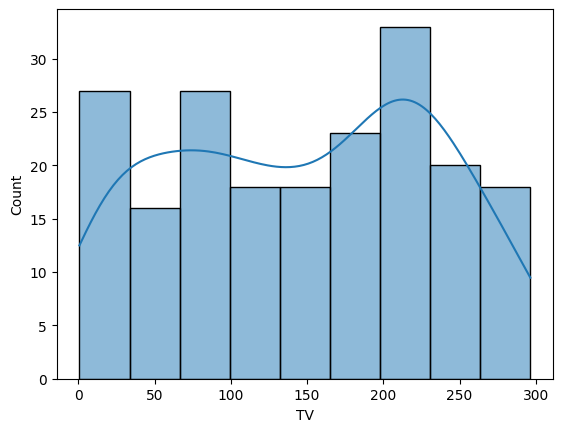

In [8]:
sns.histplot(df,x="TV",kde=True)

<Axes: xlabel='TV', ylabel='Newspaper'>

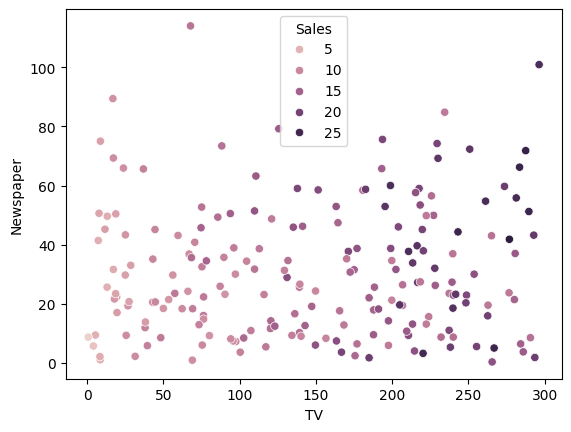

In [12]:
sns.scatterplot(df,x="TV",y="Newspaper",hue="Sales")

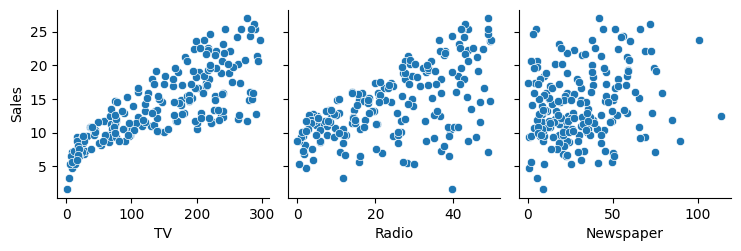

In [13]:


# 2. Relationships with Sales
sns.pairplot(df, y_vars=['Sales'], x_vars=['TV', 'Radio', 'Newspaper'])
plt.show()



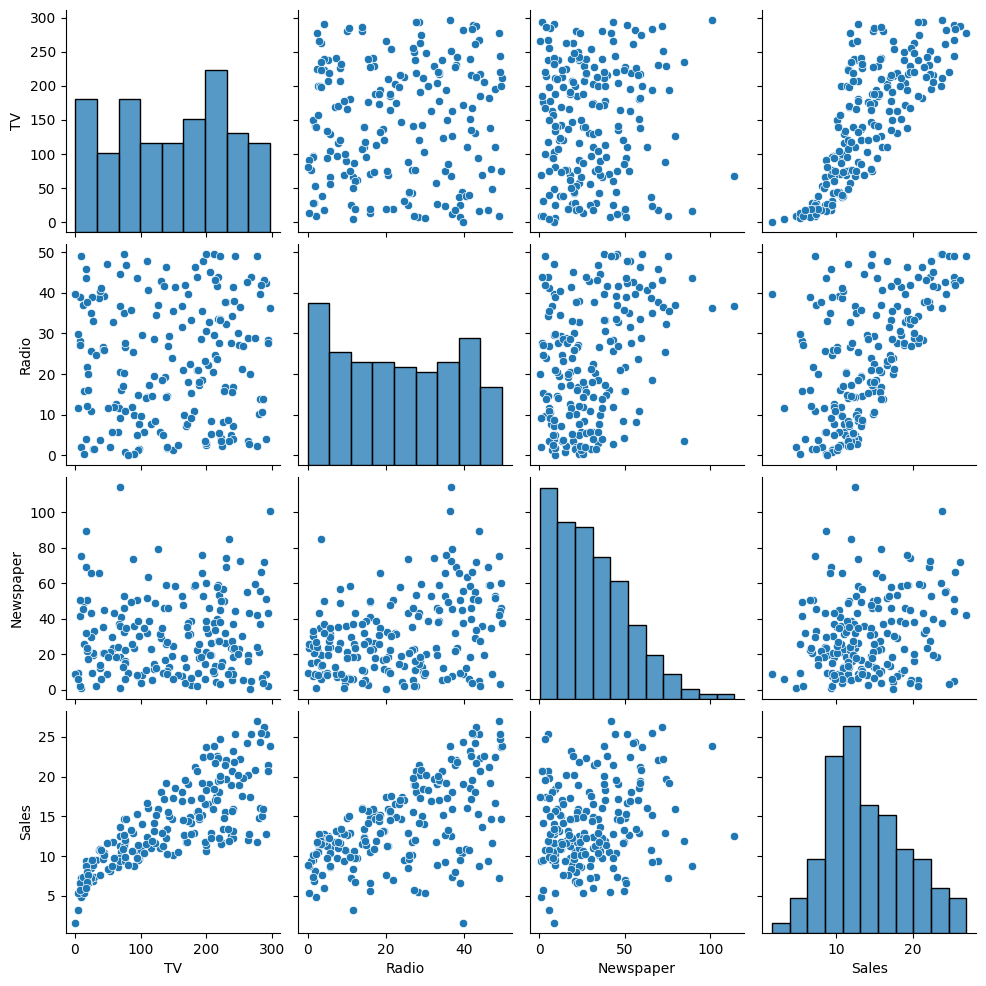

In [14]:
sns.pairplot(df)
plt.show()

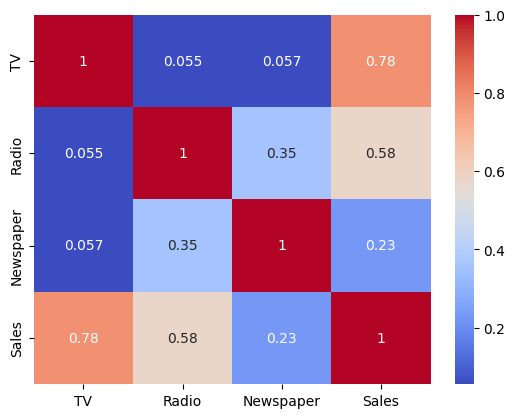

In [15]:
# 1. Correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [18]:
X=df.drop("Sales",axis=1)
y=df["Sales"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [23]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.4607567168117606
MSE: 3.1740973539761073
RMSE: 1.781599661533451
R²: 0.8994380241009119


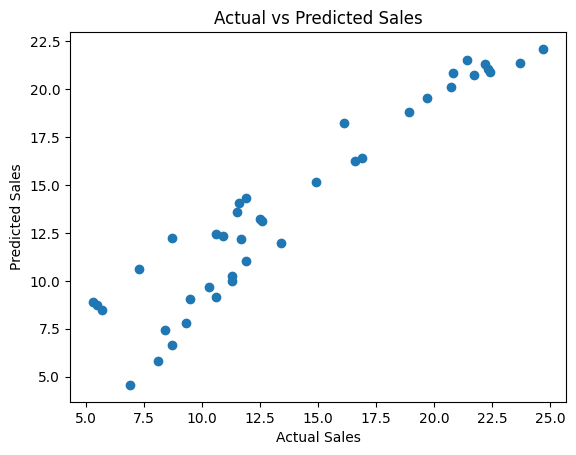

In [26]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

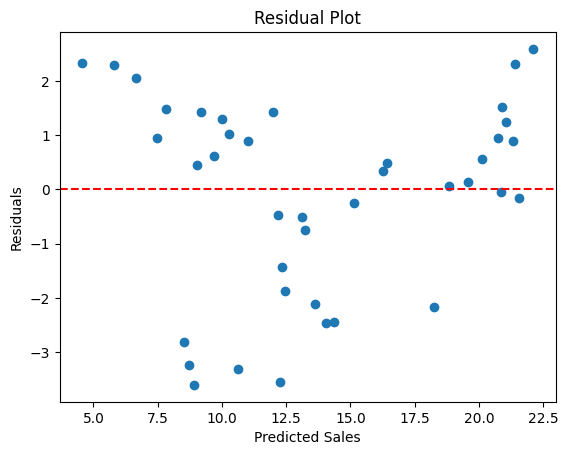

In [27]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("R²:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R²: 0.9833065804358095
MAE: 0.6084372924225304
RMSE: 0.7258817489249954


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² scores:", scores)
print("Mean R²:", scores.mean())

R² scores: [0.98111453 0.98790689 0.96937207 0.96544383 0.98713761]
Mean R²: 0.9781949859170324
